# Diabetes Risk Prediction — Multi-Class Classification

**Objective:** Predict diabetes risk level (Low / Moderate / High) from demographic, lifestyle, and clinical features using a multi-class classification approach.

**Dataset:** 15,000 patient records with 18 features (demographic, lifestyle, and clinical measurements).

**Target variable:** `diabetes_risk` — Low (60%), Moderate (25%), High (15%)

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Data cleaning & missing value handling
3. Feature encoding & train/CV/test split
4. Neural network (TensorFlow/Keras) 
5. XGBoost baseline for comparison

In [75]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & splitting ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Neural network (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras import layers, models

# --- XGBoost ---
import xgboost as xgb

# --- Evaluation ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Class balancing (sample weights for XGBoost) ---
from sklearn.utils.class_weight import compute_sample_weight

# --- Hyperparameter tuning ---
from sklearn.model_selection import GridSearchCV

# --- Plot styling ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load Data

In [5]:
df = pd.read_csv("C:\\Users\\ravic\\Downloads\\diabetes_risk.csv")

## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview
Basic shape, column types, and a first look at the data.

In [7]:
print("Shape:", df.shape)
print("\nColumn info:")
df.info()

Shape: (15000, 19)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15

In [9]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [11]:
# Numeric columns summary
print("Numeric summary:")
df.describe().T

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
patient_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
age,15000.0,44.333667,10.383753,18.0,38.00,45.0,52.00,80.0
bmi,15000.0,23.062260,4.046391,15.0,20.10,22.7,25.60,40.8
hours_sleep_per_night,15000.0,7.309860,1.109372,3.0,6.70,7.0,8.00,12.0
stress_level,15000.0,5.941200,2.148406,1.0,4.00,6.0,7.00,10.0
fasting_blood_sugar,15000.0,168.789933,38.365822,72.0,145.00,165.0,189.00,400.0
hba1c_level,15000.0,6.878387,0.843276,4.8,6.30,6.8,7.30,13.4
blood_pressure_systolic,15000.0,139.496200,12.660785,80.0,130.00,140.0,150.00,200.0
blood_pressure_diastolic,15000.0,86.256933,8.386529,50.0,80.00,88.0,90.00,120.0
waist_circumference_cm,15000.0,100.207933,10.760331,73.2,92.50,99.3,106.90,148.2


In [13]:
# Categorical columns summary
print("\nCategorical summary:")
df.describe(include='object').T


Categorical summary:


,count,unique,top,freq
gender,15000,3,Male,7664
city,15000,18,Mumbai,2243
family_history_diabetes,15000,2,No,9756
physical_activity_level,15000,3,Active,5100
diet_type,15000,4,Non-Vegetarian,8195
smoking_status,14528,3,Never,10119
alcohol_consumption,11212,3,Never,5616
income_bracket,14537,3,Middle,7305
diabetes_risk,15000,3,Low,9000


### 2.2 Missing Values
Checking which columns have missing data and how much.

                     missing_count  missing_pct
alcohol_consumption           3788    25.253333
smoking_status                 472     3.146667
income_bracket                 463     3.086667


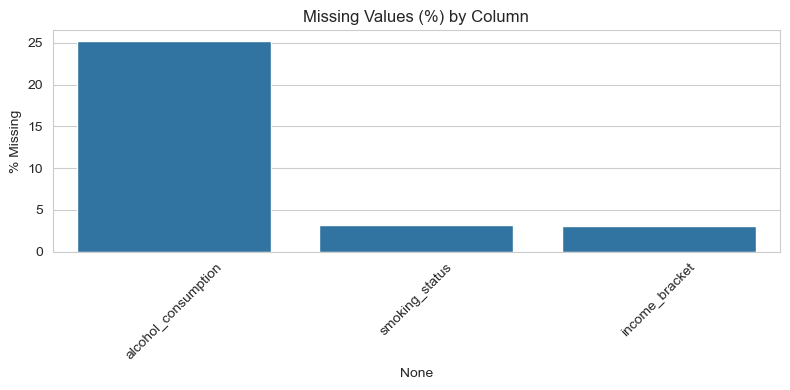

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

# Visualize
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'])
plt.title('Missing Values (%) by Column')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3 Duplicate & ID Sanity Check

In [17]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient_id:", df['patient_id'].duplicated().sum())
print("patient_id range:", df['patient_id'].min(), "-", df['patient_id'].max())

Duplicate rows: 0
Duplicate patient_id: 0
patient_id range: 1 - 15000


### 2.4 Target Variable Distribution
The target class is imbalanced (60% / 25% / 15%), which we account for later via class weighting.

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64
diabetes_risk
Low         60.0
Moderate    25.0
High        15.0
Name: proportion, dtype: float64


C:\Users\ravic\AppData\Local\Temp\ipykernel_22784\1916582598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diabetes_risk', order=order, palette='viridis')


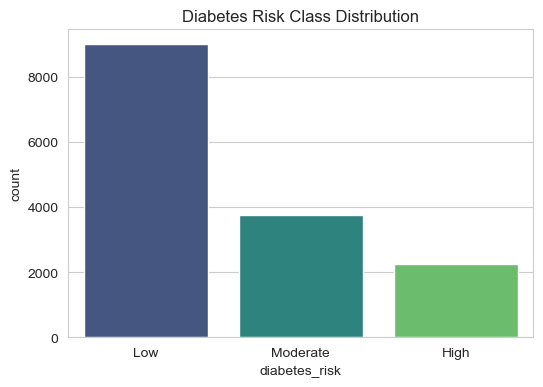

In [19]:
print(df['diabetes_risk'].value_counts())
print(df['diabetes_risk'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
order = ['Low', 'Moderate', 'High']
sns.countplot(data=df, x='diabetes_risk', order=order, palette='viridis')
plt.title('Diabetes Risk Class Distribution')
plt.show()

### 2.5 Numeric Feature Distributions

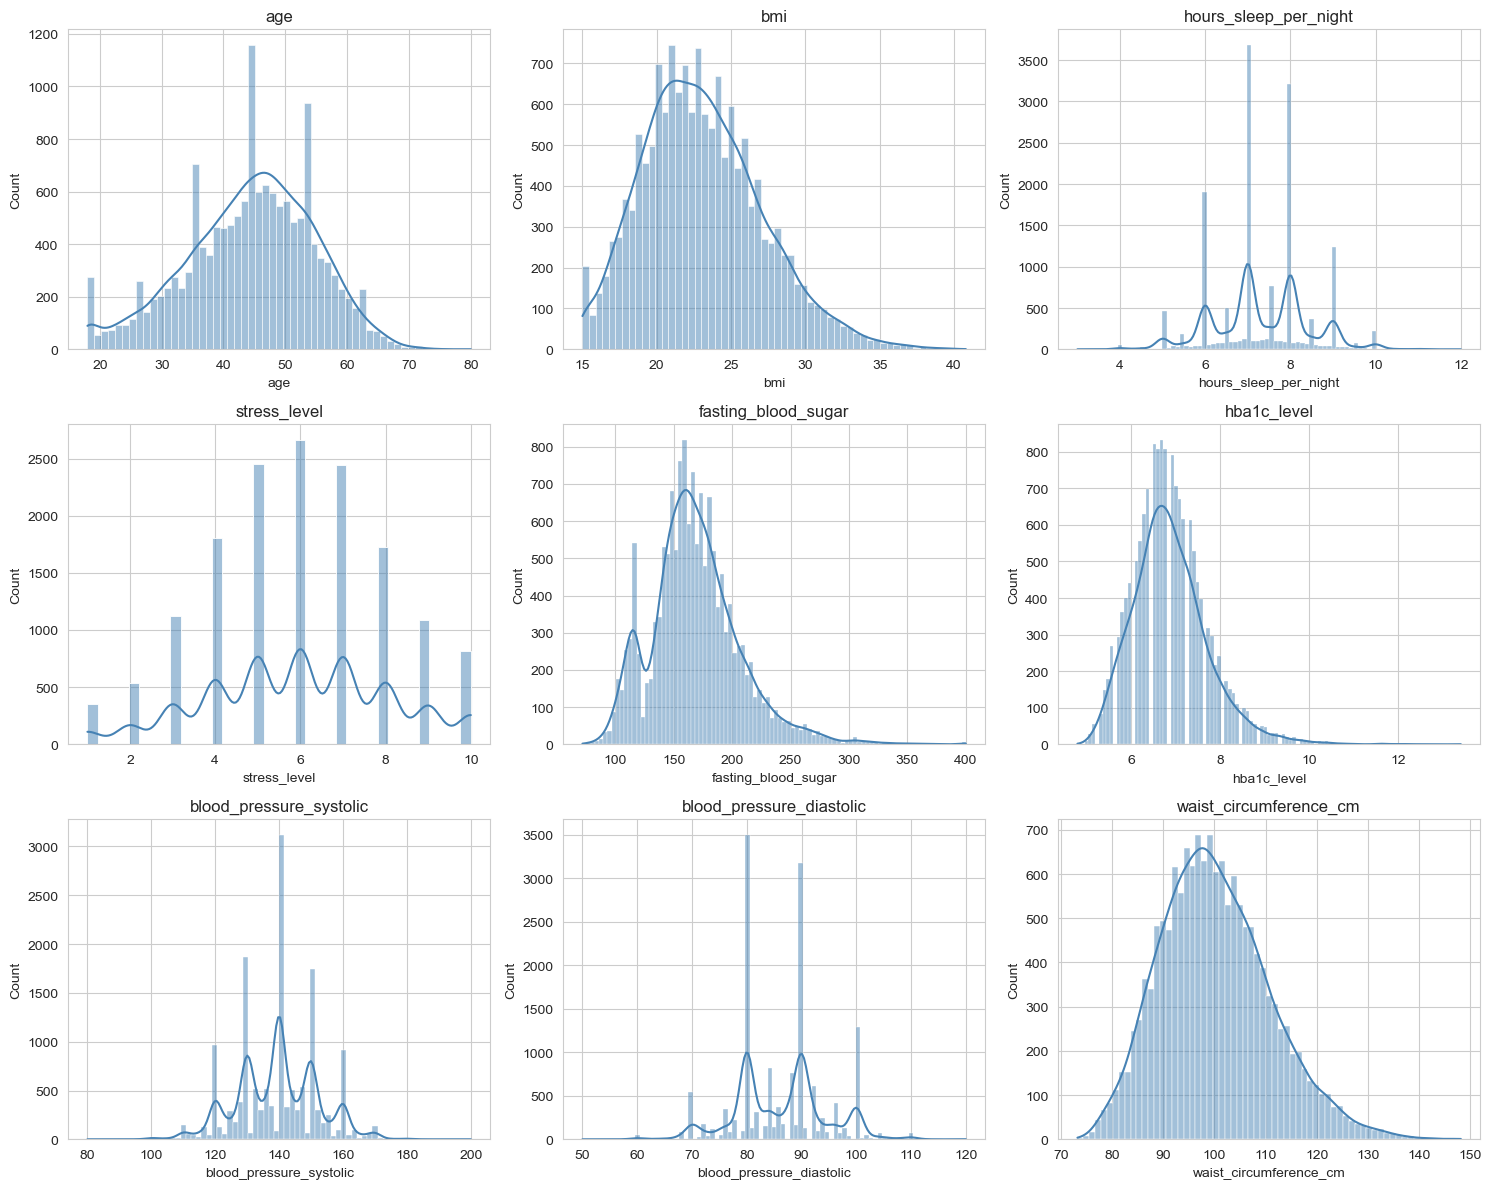

In [21]:
numeric_cols = ['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
                 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
                 'blood_pressure_diastolic', 'waist_circumference_cm']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 2.6 Numeric Features vs. Target
`fasting_blood_sugar` and `hba1c_level` show the clearest separation across risk classes — likely the strongest predictors.

C:\Users\ravic\AppData\Local\Temp\ipykernel_22784\3767177541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y=col, order=order, ax=axes[i], palette='viridis')
C:\Users\ravic\AppData\Local\Temp\ipykernel_22784\3767177541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y=col, order=order, ax=axes[i], palette='viridis')
C:\Users\ravic\AppData\Local\Temp\ipykernel_22784\3767177541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y=col, order=order, ax

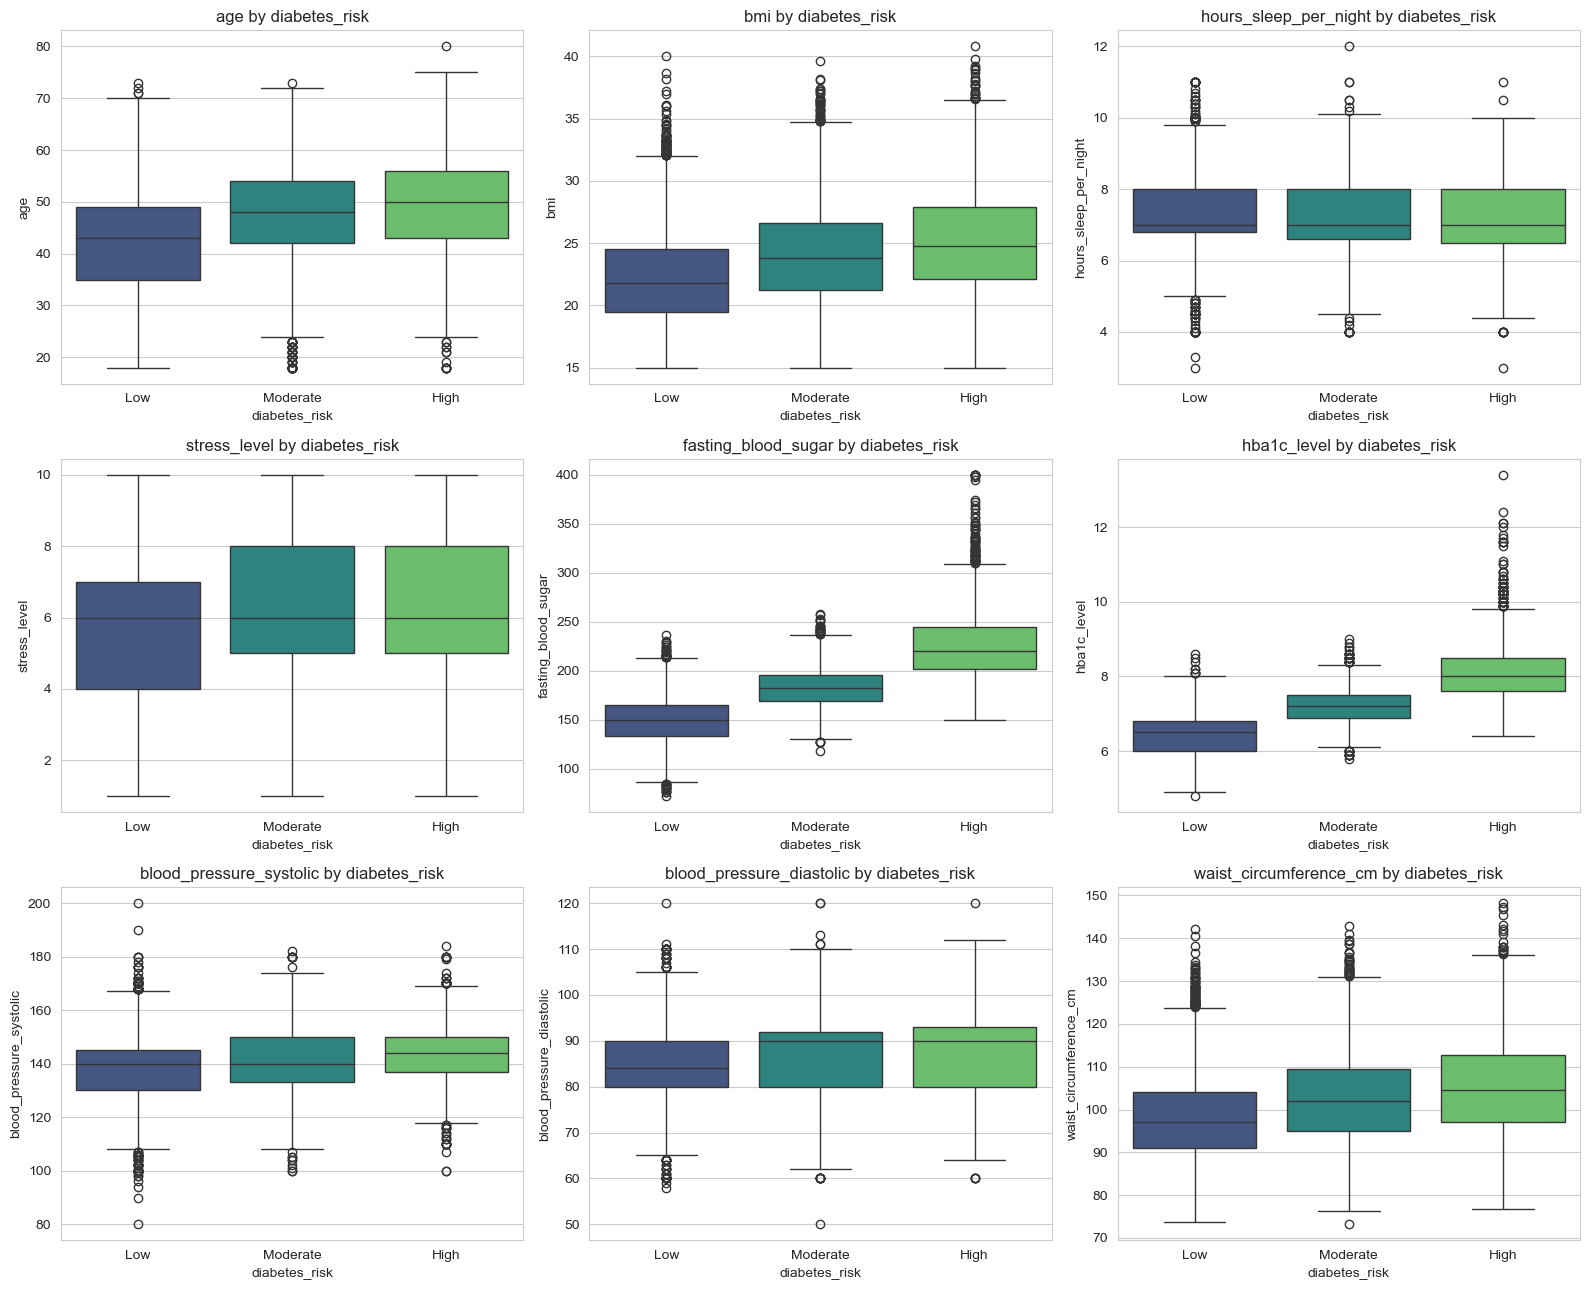

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='diabetes_risk', y=col, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} by diabetes_risk')
plt.tight_layout()
plt.show()

### 2.7 Categorical Features vs. Target

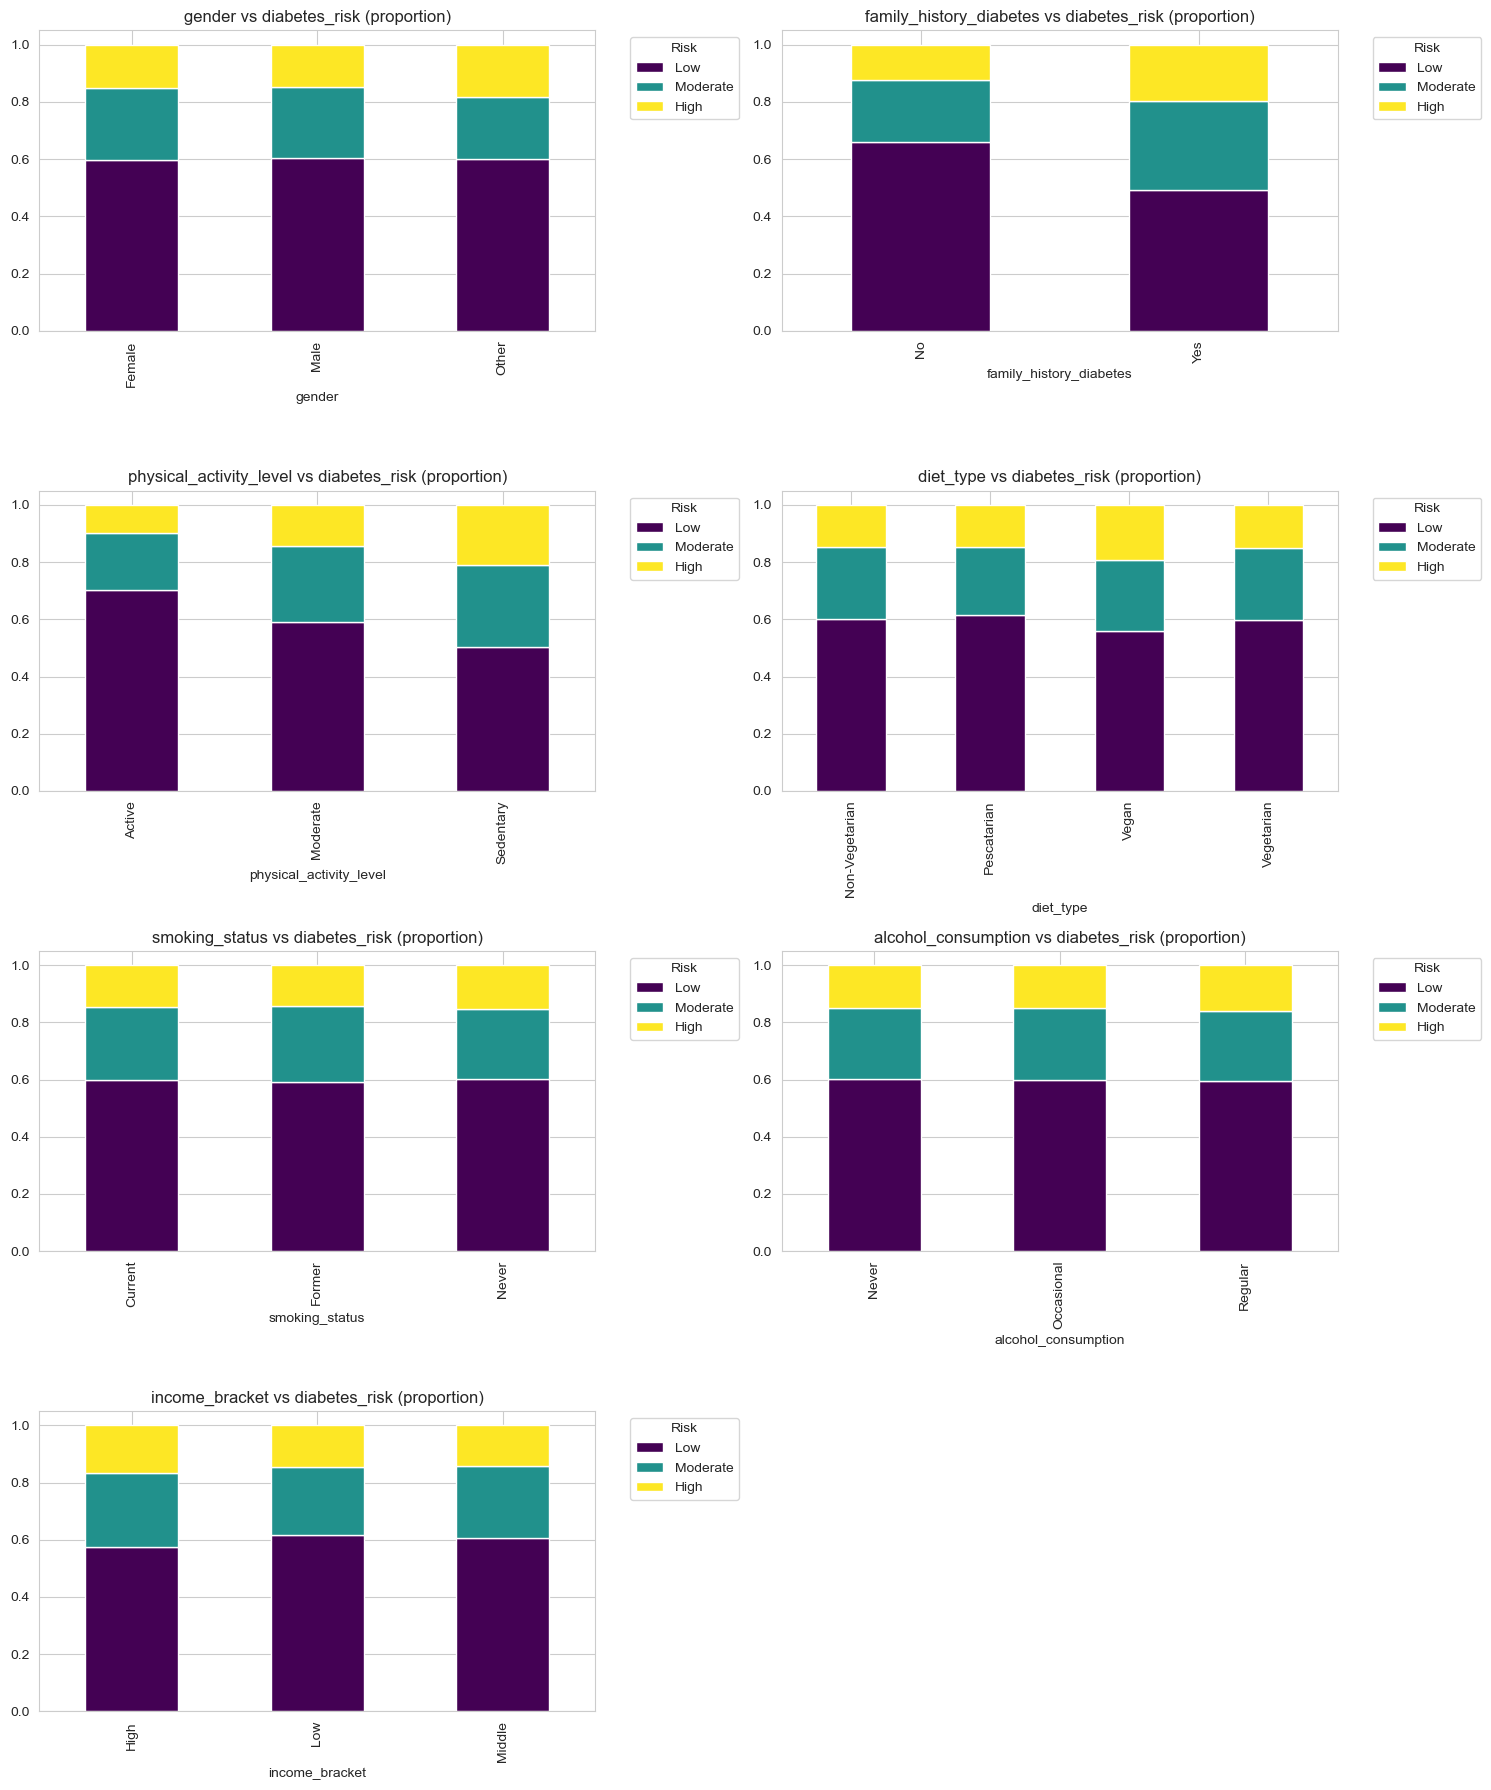

In [25]:
cat_cols = ['gender', 'family_history_diabetes', 'physical_activity_level',
            'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['diabetes_risk'], normalize='index')[order]
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs diabetes_risk (proportion)')
    axes[i].legend(title='Risk', bbox_to_anchor=(1.05, 1))
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 2.8 Correlation Analysis
Notable correlations: `bmi` ↔ `waist_circumference_cm` (0.94), `fasting_blood_sugar` ↔ `hba1c_level` (0.91).

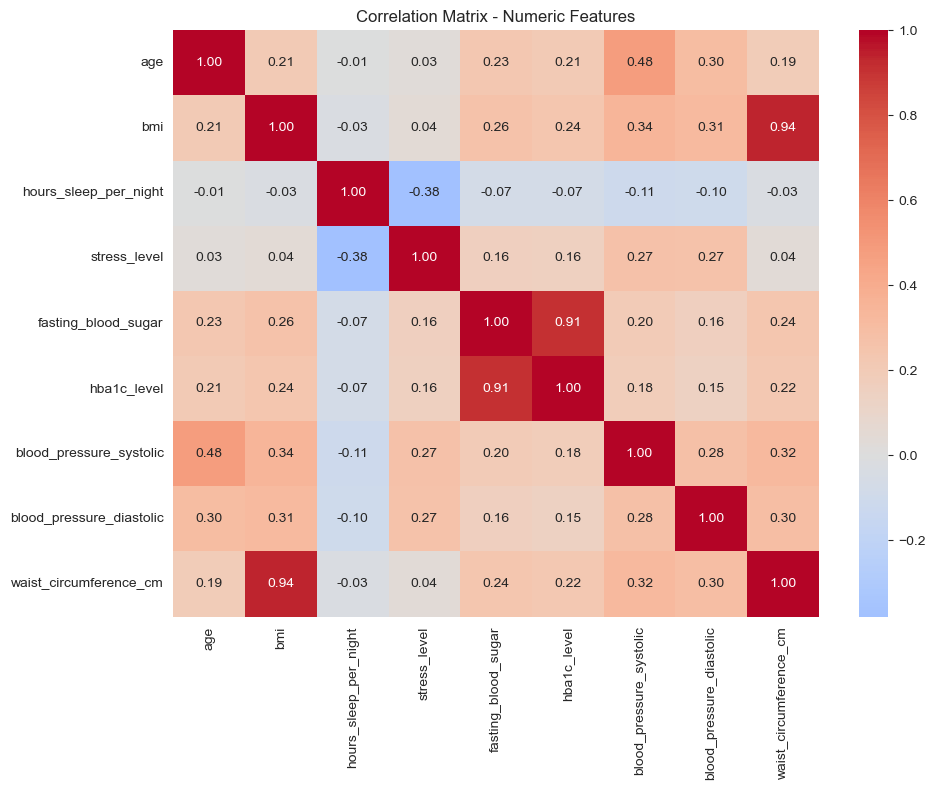

In [27]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

### 2.9 Outlier Detection (IQR Method)

In [29]:
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

age: 3 outliers (0.02%)
bmi: 153 outliers (1.02%)
hours_sleep_per_night: 360 outliers (2.40%)
stress_level: 0 outliers (0.00%)
fasting_blood_sugar: 432 outliers (2.88%)
hba1c_level: 355 outliers (2.37%)
blood_pressure_systolic: 11 outliers (0.07%)
blood_pressure_diastolic: 213 outliers (1.42%)
waist_circumference_cm: 167 outliers (1.11%)


### 2.10 Categorical Cardinality Check

In [31]:
print("Unique cities:", df['city'].nunique())
print(df['city'].value_counts())

Unique cities: 18
city
Mumbai           2243
Delhi            1737
Bengaluru        1535
Hyderabad        1227
Ahmedabad        1039
Chennai           933
Kolkata           872
Pune              756
Surat             734
Jaipur            627
Kanpur            475
Nagpur            462
Indore            458
Lucknow           457
Thane             451
Bhopal            399
Visakhapatnam     307
Patna             288
Name: count, dtype: int64


## 3. Missing Value Handling

### 3.1 Is Missingness Random or Informative?
Before imputing, we check whether missing values correlate with the target — if they did, dropping/imputing naively could remove signal.

**Finding:** Missingness rate is nearly identical across risk classes for all three columns → safe to impute (MCAR/MAR), not informative of risk.

In [33]:
# Does missingness in one column relate to another column or to the target?
for col in ['alcohol_consumption', 'smoking_status', 'income_bracket']:
    print(f"\n--- Missingness in {col} vs diabetes_risk ---")
    print(df.groupby(df[col].isnull())['diabetes_risk'].value_counts(normalize=True).unstack())

# Check unique values actually present (maybe 'Never' is a valid category and missing means something else)
print("\nalcohol_consumption values:", df['alcohol_consumption'].unique())
print("smoking_status values:", df['smoking_status'].unique())
print("income_bracket values:", df['income_bracket'].unique())


--- Missingness in alcohol_consumption vs diabetes_risk ---
diabetes_risk            High       Low  Moderate
alcohol_consumption                              
False                0.151088  0.599269  0.249643
True                 0.146779  0.602165  0.251056

--- Missingness in smoking_status vs diabetes_risk ---
diabetes_risk       High       Low  Moderate
smoking_status                              
False           0.150124  0.600633  0.249243
True            0.146186  0.580508  0.273305

--- Missingness in income_bracket vs diabetes_risk ---
diabetes_risk       High       Low  Moderate
income_bracket                              
False           0.148793  0.600605  0.250602
True            0.187905  0.580994  0.231102

alcohol_consumption values: ['Never' 'Regular' 'Occasional' nan]
smoking_status values: ['Never' 'Current' nan 'Former']
income_bracket values: ['High' 'Low' 'Middle' nan]


### 3.2 Impute Categorical Missing Values
Filled with `"Unknown"` rather than mode imputation — this avoids fabricating data (especially for `alcohol_consumption`, 25% missing) while letting the model use missingness as information if relevant.

In [35]:
for col in ['alcohol_consumption', 'smoking_status', 'income_bracket']:
    df[col] = df[col].fillna('Unknown')

# Verify
print(df[['alcohol_consumption', 'smoking_status', 'income_bracket']].isnull().sum())
print(df['alcohol_consumption'].value_counts())
print(df['smoking_status'].value_counts())
print(df['income_bracket'].value_counts())

alcohol_consumption    0
smoking_status         0
income_bracket         0
dtype: int64
alcohol_consumption
Never         5616
Occasional    4483
Unknown       3788
Regular       1113
Name: count, dtype: int64
smoking_status
Never      10119
Current     2946
Former      1463
Unknown      472
Name: count, dtype: int64
income_bracket
Middle     7305
High       3844
Low        3388
Unknown     463
Name: count, dtype: int64


### 3.3 Verify No Missing Values Remain

In [37]:
print("Total missing values remaining:", df.isnull().sum().sum())
df.isnull().sum()

Total missing values remaining: 0


patient_id                  0
age                         0
gender                      0
city                        0
bmi                         0
family_history_diabetes     0
physical_activity_level     0
diet_type                   0
smoking_status              0
alcohol_consumption         0
hours_sleep_per_night       0
stress_level                0
fasting_blood_sugar         0
hba1c_level                 0
blood_pressure_systolic     0
blood_pressure_diastolic    0
waist_circumference_cm      0
income_bracket              0
diabetes_risk               0
dtype: int64

## 4. Feature Engineering & Preprocessing

### 4.1 Target Encoding
Encoded target with explicit order: Low=0, Moderate=1, High=2.

In [53]:
# Drop patient_id (not a predictive feature)
df_model = df.drop(columns=['patient_id'])

# Encode target: Low=0, Moderate=1, High=2 (explicit order, not alphabetical)
risk_order = {'Low': 0, 'Moderate': 1, 'High': 2}
df_model['diabetes_risk_encoded'] = df_model['diabetes_risk'].map(risk_order)

X = df_model.drop(columns=['diabetes_risk', 'diabetes_risk_encoded'])
y = df_model['diabetes_risk_encoded']

print(X.dtypes)
print(y.value_counts())

age                           int64
gender                       object
city                         object
bmi                         float64
family_history_diabetes      object
physical_activity_level      object
diet_type                    object
smoking_status               object
alcohol_consumption          object
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket               object
dtype: object
diabetes_risk_encoded
0    9000
1    3750
2    2250
Name: count, dtype: int64


### 4.2 Categorical Feature Encoding
One-hot encoded all categorical columns.

In [55]:
categorical_cols = ['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
                     'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']
numeric_cols = ['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
                 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
                 'blood_pressure_diastolic', 'waist_circumference_cm']

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (15000, 51)


,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,gender_Female,...,smoking_status_Never,smoking_status_Unknown,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,alcohol_consumption_Unknown,income_bracket_High,income_bracket_Low,income_bracket_Middle,income_bracket_Unknown
0,47,26.5,9.0,8,178,7.3,146,90,107.1,True,...,True,False,True,False,False,False,True,False,False,False
1,53,20.5,7.0,6,152,6.9,156,100,93.8,True,...,True,False,True,False,False,False,False,True,False,False
2,47,31.3,7.0,7,168,6.6,150,102,113.5,False,...,False,False,False,False,True,False,False,True,False,False
3,41,22.8,9.0,5,155,6.7,126,92,109.6,False,...,True,False,True,False,False,False,False,False,True,False
4,57,16.7,6.5,10,188,6.7,130,90,80.8,True,...,False,False,False,True,False,False,True,False,False,False


### 4.3 Train / CV / Test Split
70% train / 15% CV / 15% test, stratified to preserve the 60/25/15 class ratio in every split.

In [57]:
# First split: separate out test set (e.g. 70% train+cv, 15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: split remaining into train and cv (validation)
# 0.1765 of the 85% remaining ≈ 15% of the original total
X_train, X_cv, y_train, y_cv = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("CV shape:", X_cv.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("CV class balance:\n", y_cv.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (10499, 51)
CV shape: (2251, 51)
Test shape: (2250, 51)

Train class balance:
 diabetes_risk_encoded
0    0.600057
1    0.249929
2    0.150014
Name: proportion, dtype: float64
CV class balance:
 diabetes_risk_encoded
0    0.599733
1    0.250111
2    0.150155
Name: proportion, dtype: float64
Test class balance:
 diabetes_risk_encoded
0    0.600000
1    0.250222
2    0.149778
Name: proportion, dtype: float64


### 4.4 Feature Scaling
Standardized numeric features (fit only on training data to avoid leakage).

In [59]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_cv_scaled = X_cv.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_cv_scaled[numeric_cols] = scaler.transform(X_cv[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_final = X_train_scaled.astype('float32').values
X_cv_final = X_cv_scaled.astype('float32').values
X_test_final = X_test_scaled.astype('float32').values

print(X_train_final.shape, X_cv_final.shape, X_test_final.shape)

(10499, 51) (2251, 51) (2250, 51)


### 4.5 Class Weights for Imbalanced Target
Computed balanced class weights to prevent the model from over-favoring the majority "Low" class.

In [61]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.5555026455026455, 1: 1.333714430894309, 2: 2.222010582010582}


## 5. Neural Network Model (TensorFlow/Keras) — Baseline

### 5.1 Model Architecture
Fully connected network with dropout regularization; 3-neuron softmax output layer for class probabilities. Architecture and hyperparameters (layer sizes, dropout rates, learning rate) were manually chosen, not tuned.

In [116]:

tf.random.set_seed(42)

n_features = X_train_final.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')   # 3 neurons, one probability per class
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │           3,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,987 (23.39 KB)

 Trainable params: 5,987 (23.39 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compile Model

In [65]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',   # y is integer-encoded (0,1,2), not one-hot
    metrics=['accuracy']
)

### 5.3 Train Model
Using explicit CV set for validation (not `validation_split`) and early stopping on validation loss.

In [67]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_final, y_train,
    validation_data=(X_cv_final, y_cv),   # explicit CV set now
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6544 - loss: 0.8183 - val_accuracy: 0.7574 - val_loss: 0.5211
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7365 - loss: 0.6087 - val_accuracy: 0.7654 - val_loss: 0.5143
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7528 - loss: 0.5681 - val_accuracy: 0.7623 - val_loss: 0.5090
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7568 - loss: 0.5599 - val_accuracy: 0.7690 - val_loss: 0.5049
Epoch 5/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7642 - loss: 0.5496 - val_accuracy: 0.7668 - val_loss: 0.5017
Epoch 6/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7625 - loss: 0.5443 - val_accuracy: 0.7699 - val_loss: 0.4949
Epoch 7/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7655 - loss: 0.5310 - val_accuracy: 0.7659 - val_loss: 0.5040
Epoch 8/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7629 - loss: 0.5309 - val_accu

### 5.4 Training Curves

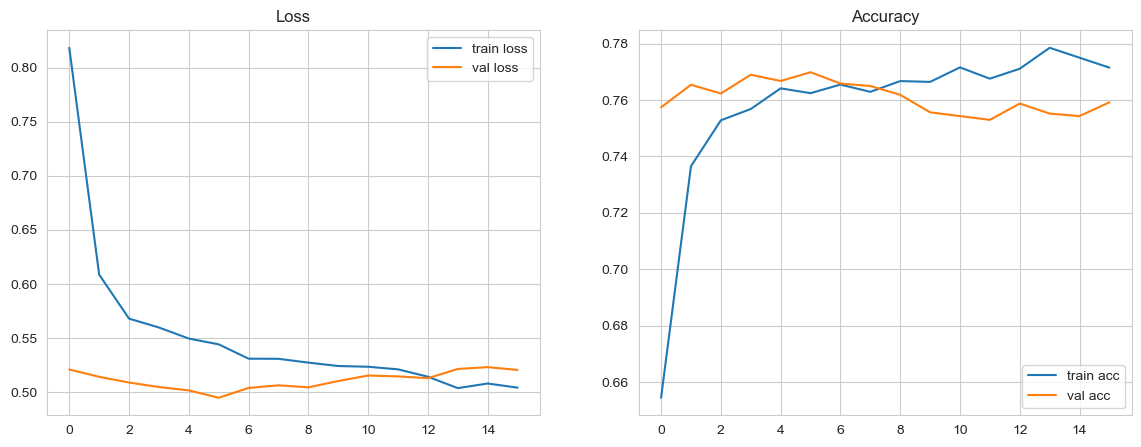

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train acc')
axes[1].plot(history.history['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()

### 5.5 Model Evaluation (CV & Test)

**Result:** Test Accuracy 77.5%, Macro F1 0.74 (baseline architecture, untuned). Strong performance on Low and High classes; Moderate class remains the hardest to separate.

CV Accuracy: 0.7699, CV Loss: 0.4949
Test Accuracy: 0.7751, Test Loss: 0.4981
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

         Low       0.90      0.83      0.86      1350
    Moderate       0.55      0.65      0.60       563
        High       0.74      0.77      0.76       337

    accuracy                           0.78      2250
   macro avg       0.73      0.75      0.74      2250
weighted avg       0.79      0.78      0.78      2250



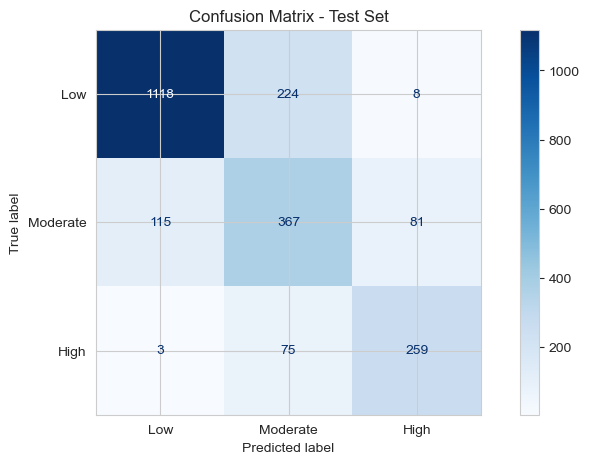

In [71]:
cv_loss, cv_acc = model.evaluate(X_cv_final, y_cv, verbose=0)
print(f"CV Accuracy: {cv_acc:.4f}, CV Loss: {cv_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test_final, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Moderate', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

## 6. XGBoost Baseline (Model Comparison)

For tabular data of this size, tree-based ensembles are a natural comparison point against the neural network.

### 6.1 Sample Weights for Class Imbalance

In [77]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

### 6.2 Train XGBoost Model

In [80]:
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_cv, y_cv)],
    verbose=True
)

[0]	validation_0-mlogloss:1.06115
[1]	validation_0-mlogloss:1.02721
[2]	validation_0-mlogloss:0.99643
[3]	validation_0-mlogloss:0.96737
[4]	validation_0-mlogloss:0.94053
[5]	validation_0-mlogloss:0.91533
[6]	validation_0-mlogloss:0.89198
[7]	validation_0-mlogloss:0.87033
[8]	validation_0-mlogloss:0.85554
[9]	validation_0-mlogloss:0.83695
[10]	validation_0-mlogloss:0.81915
[11]	validation_0-mlogloss:0.80314
[12]	validation_0-mlogloss:0.78770
[13]	validation_0-mlogloss:0.77262
[14]	validation_0-mlogloss:0.75893
[15]	validation_0-mlogloss:0.74608
[16]	validation_0-mlogloss:0.73370
[17]	validation_0-mlogloss:0.72230
[18]	validation_0-mlogloss:0.71191
[19]	validation_0-mlogloss:0.70211
[20]	validation_0-mlogloss:0.69265
[21]	validation_0-mlogloss:0.68352
[22]	validation_0-mlogloss:0.67492
[23]	validation_0-mlogloss:0.66761
[24]	validation_0-mlogloss:0.65965
[25]	validation_0-mlogloss:0.65239
[26]	validation_0-mlogloss:0.64527
[27]	validation_0-mlogloss:0.63886
[28]	validation_0-mlogloss:0.6

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

### 6.3 XGBoost Evaluation

**Result:** Test Accuracy 76.0%, Macro F1 0.72 — slightly behind the tuned neural network on this dataset.

CV Accuracy: 0.7641048422923146
Test Accuracy: 0.7595555555555555

Classification Report (Test):
              precision    recall  f1-score   support

         Low       0.91      0.81      0.85      1350
    Moderate       0.52      0.67      0.59       563
        High       0.73      0.72      0.72       337

    accuracy                           0.76      2250
   macro avg       0.72      0.73      0.72      2250
weighted avg       0.79      0.76      0.77      2250



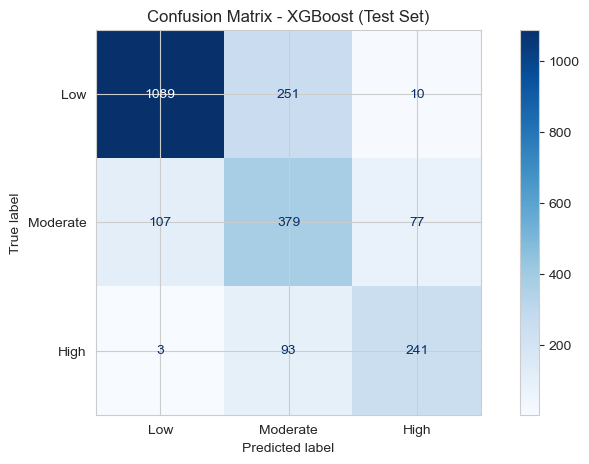

In [82]:
cv_pred = xgb_model.predict(X_cv)
test_pred = xgb_model.predict(X_test)

print("CV Accuracy:", accuracy_score(y_cv, cv_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=['Low', 'Moderate', 'High']))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Moderate', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost (Test Set)')
plt.show()

## 7. Summary & Conclusions

| Metric | Neural Network (baseline) | XGBoost (baseline) |
|---|---|---|
| Test Accuracy | 77.5% | 76.0% |
| Low F1 | 0.86 | 0.85 |
| Moderate F1 | 0.60 | 0.59 |
| High F1 | 0.76 | 0.72 |
| Macro F1 | 0.74 | 0.72 |

**Key findings:**
- The neural network with class weighting outperformed the untuned XGBoost baseline on this dataset.
- `fasting_blood_sugar` and `hba1c_level` were the strongest predictors of diabetes risk, consistent with clinical expectations.
- The "Moderate" risk class was consistently the hardest to classify across both models, likely because it represents a transitional zone between Low and High risk on continuous clinical markers rather than a distinctly separable group.
- Class imbalance (60/25/15) was addressed via class weighting; this improved minority class recall at some cost to overall accuracy.

**Possible future work:**
- Hyperparameter tuning for the neural network (Keras Tuner)
- Hyperparameter tuning for XGBoost (Randomized/Grid search)
- SMOTE oversampling for the Moderate class
- Feature engineering (e.g., combining highly correlated features like `bmi` and `waist_circumference_cm`)